--- Final Model Metrics ---
                     Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression     1.000      1.000   1.000  1.000    1.000
Random Forest           0.965      0.947   0.991  0.968    0.998

LR Cross-Val Score: 0.994
RF Cross-Val Score: 0.957



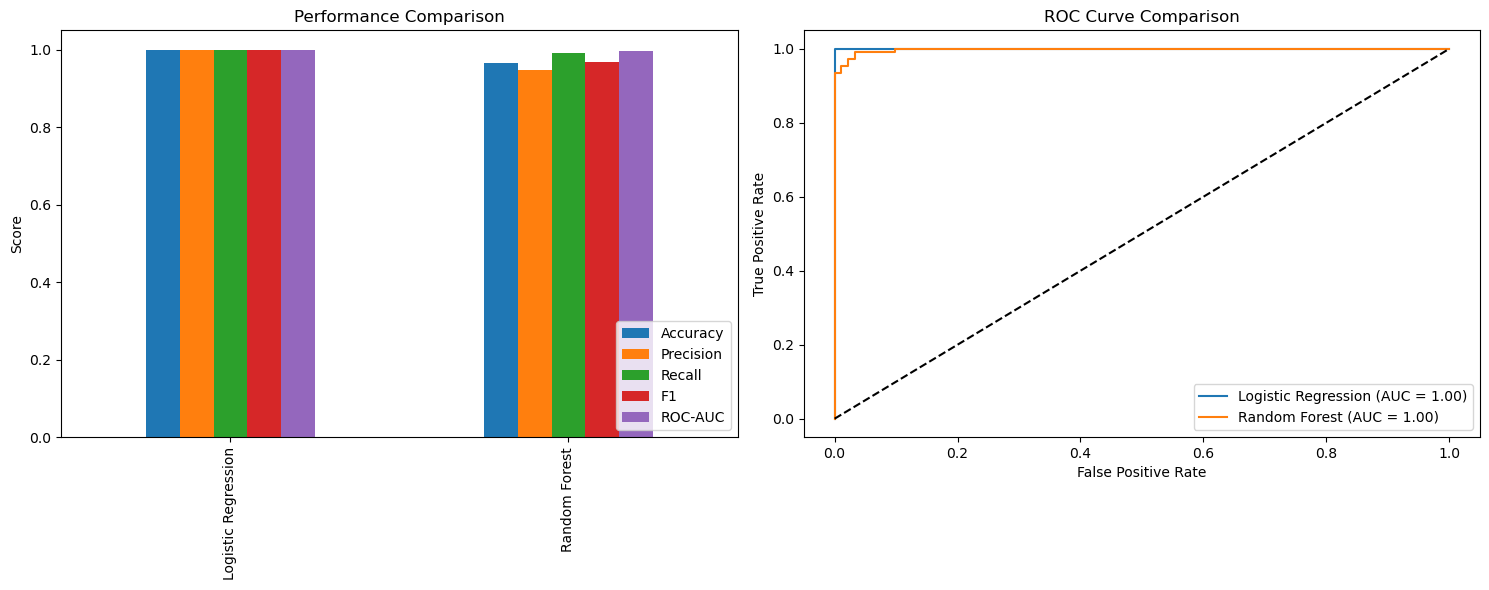

In [6]:
## IPL Match Prediction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# 1. Data Generation
np.random.seed(42)
n_matches = 1000

home_form = np.random.uniform(40, 85, n_matches)
away_form = np.random.uniform(40, 85, n_matches)
home_toss = np.random.randint(0, 2, n_matches)
is_day_match = np.random.randint(0, 2, n_matches)
home_rest = np.random.randint(2, 7, n_matches)
away_rest = np.random.randint(2, 7, n_matches)

# Target: Home win logic
match_score = (home_form - away_form) + (home_toss * 5) + (home_rest - away_rest)
home_wins = (match_score > 0).astype(int)

df = pd.DataFrame({
    "home_team_form": home_form,
    "away_team_form": away_form,
    "home_won_toss": home_toss,
    "day_match": is_day_match,
    "home_rest_days": home_rest,
    "away_rest_days": away_rest,
    "home_win": home_wins
})

# 2. Preprocessing
X = df.drop("home_win", axis=1)
y = df["home_win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features (Required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  3. Model Training & Cross-Validation 
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5).mean()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cv = cross_val_score(rf, X_train, y_train, cv=5).mean()
rf.fit(X_train, y_train)

# Evaluation Metrics 
def evaluate(model, X_set, y_true):
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)[:, 1]
    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds),
        "Recall": recall_score(y_true, preds),
        "F1": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, probs)
    }

lr_metrics = evaluate(lr, X_test_scaled, y_test)
rf_metrics = evaluate(rf, X_test, y_test)

results_df = pd.DataFrame([lr_metrics, rf_metrics], 
                          index=["Logistic Regression", "Random Forest"])

print("--- Final Model Metrics ---")
print(results_df.round(3))
print(f"\nLR Cross-Val Score: {lr_cv:.3f}")
print(f"RF Cross-Val Score: {rf_cv:.3f}\n")

#5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart for Metrics
results_df.plot(kind="bar", ax=ax1)
ax1.set_title("Performance Comparison")
ax1.set_ylabel("Score")
ax1.legend(loc='lower right')

# ROC Curve Plot
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

ax2.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_metrics["ROC-AUC"]:.2f})')
ax2.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_metrics["ROC-AUC"]:.2f})')
ax2.plot([0, 1], [0, 1], 'k--') # Random chance line
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve Comparison')
ax2.legend()

plt.tight_layout()
plt.show()